# Projet d’Analyse Numérique : Étude complète du pendule non-linéaire : trajectoires, énergie, équilibres et chaos

## Partie 1 : Résolution de l’EDO et stabilité de l’énergie

### 1. Mise en équation

Pour obtenir un système différentiel d'ordre 1, dérivons $Y(t)$ :
$$Y'(t) = \begin{pmatrix} \theta'(t) \\ v'(t) \end{pmatrix}$$

Puisque $\theta'(t) = v(t)$ et que l'on peut déduire $v'(t) = \theta''(t) = -\omega^2 \sin(\theta(t))$ à partir de l'équation initiale, le système s'écrit finalement :
$$Y'(t) = \begin{pmatrix} v(t) \\ -\omega^2 \sin(\theta(t)) \end{pmatrix}$$

### 2. Implémentation Python

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Définition du système différentiel du pendule
def pendule_systeme(t, Y):
    
    theta = Y[0]
    v = Y[1]
    omega = 1.0 
    dtheta = v
    dv = - (omega**2) * np.sin(theta)
    
    return np.array([dtheta, dv])


In [57]:
# Méthode d’Euler explicite
def euler_explicite(f, Y0, Tmax, h):

    N = int(Tmax / h)
    t = np.linspace(0, Tmax, N + 1) 
    
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    
    for n in range(len(t) - 1):
        Y[n+1] = Y[n] + h * f(t[n], Y[n])
        
    return t, Y


In [58]:
# Méthode de Heun (RK2)
def heun(f, Y0, Tmax, h):
    
    N = int(Tmax / h)
    t = np.linspace(0, Tmax, N + 1)
    
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    
    for n in range(len(t) - 1):
        p1 = f(t[n], Y[n])
        
        p2 = f(t[n] + h, Y[n] + h * p1)
        
        Y[n+1] = Y[n] + (h / 2) * (p1 + p2)
        
    return t, Y


In [59]:
# Méthode de Runge-Kutta classique d'ordre 4 (RK4)
def rk4(f, Y0, Tmax, h):
    
    N = int(Tmax / h)
    t = np.linspace(0, Tmax, N + 1)
    
    Y = np.zeros((len(t), len(Y0)))
    Y[0] = Y0
    
    for n in range(len(t) - 1):
        p1 = f(t[n], Y[n])
        
        p2 = f(t[n] + h/2, Y[n] + (h/2) * p1)
        
        p3 = f(t[n] + h/2, Y[n] + (h/2) * p2)
        
        p4 = f(t[n] + h, Y[n] + h * p3)
    
        Y[n+1] = Y[n] + (h / 6) * (p1 + 2*p2 + 2*p3 + p4)
        
    return t, Y


### 3. Visualisation

Le pendule est lâché sans vitesse initiale, la condition initiale est donc $Y_0 = \begin{pmatrix} \pi/2 \\ 0 \end{pmatrix}$.

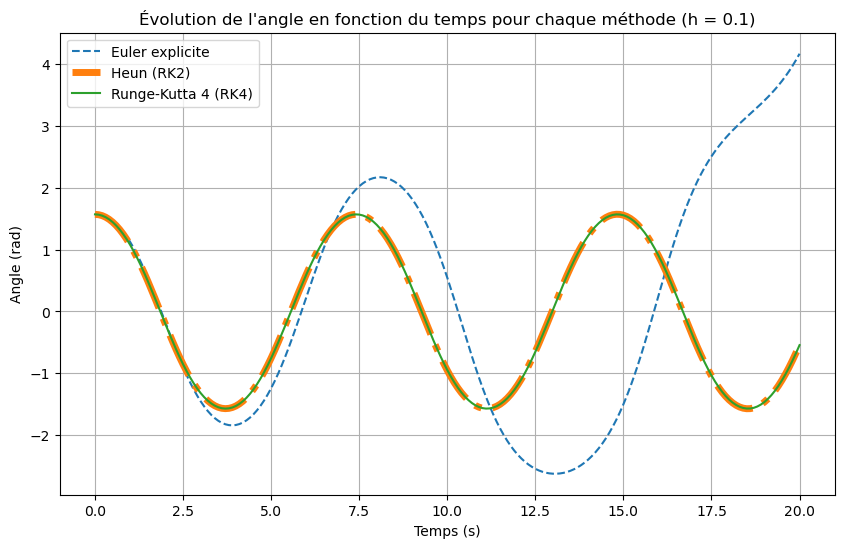

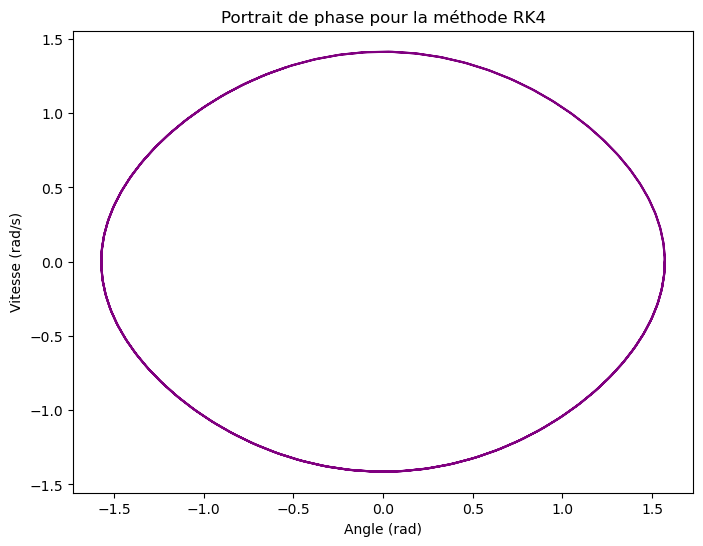

In [60]:
# 1. Définition des paramètres de l'énoncé
theta0 = np.pi / 2
v0 = 0.0
Y0 = np.array([theta0, v0])
Tmax = 20.0
h = 0.1

# 2. Exécution des trois méthodes
t_euler, Y_euler = euler_explicite(pendule_systeme, Y0, Tmax, h)
t_heun, Y_heun = heun(pendule_systeme, Y0, Tmax, h)
t_rk4, Y_rk4 = rk4(pendule_systeme, Y0, Tmax, h)

# 3. Extraction des angles (et de la vitesse pour RK4)
theta_euler = Y_euler[:, 0]
theta_heun = Y_heun[:, 0]
theta_rk4 = Y_rk4[:, 0]
v_rk4 = Y_rk4[:, 1]

# Premier graphique : les angles en fonction du temps
plt.figure(figsize=(10, 6))
plt.plot(t_euler, theta_euler, label="Euler explicite", linestyle='--')
plt.plot(t_heun, theta_heun, label="Heun (RK2)", linestyle='-.', linewidth = 5)
plt.plot(t_rk4, theta_rk4, label="Runge-Kutta 4 (RK4)")

plt.title("Évolution de l'angle en fonction du temps pour chaque méthode (h = 0.1)")
plt.xlabel("Temps (s)")
plt.ylabel("Angle (rad)")
plt.legend()
plt.grid(True)
plt.show()

# Deuxième graphique : le portrait de phase pour RK4
plt.figure(figsize=(8, 6))
plt.plot(theta_rk4, v_rk4, color='purple')

plt.title("Portrait de phase pour la méthode RK4")
plt.xlabel("Angle (rad)")
plt.ylabel("Vitesse (rad/s)")
plt.grid(False)
plt.show()

Dans le premier graphique, avec un pas $h=0.1$ sur une durée de 20 secondes, les algorithmes RK4 et RK2 sont suffisamment précis pour que leurs courbes semblent parfaitement se superposer.

### 4. Analyse d’énergie (Réflexion théorique)

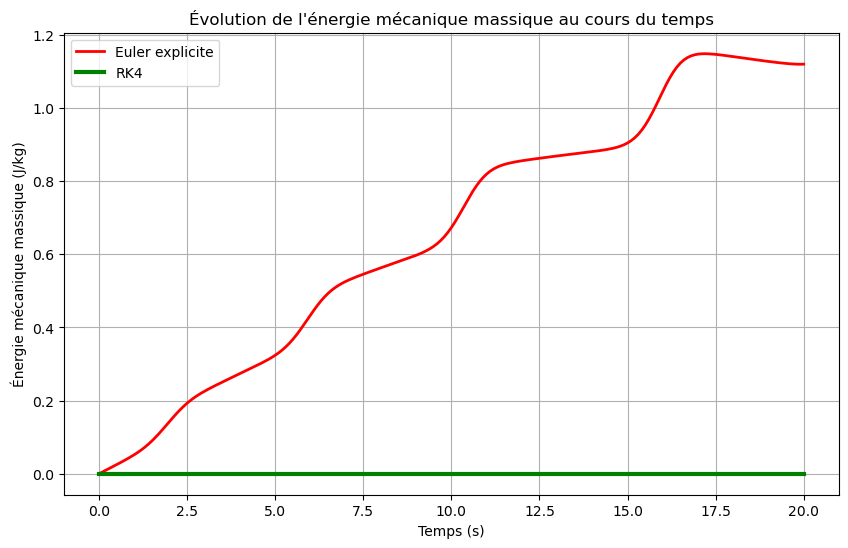

In [64]:
# Extraction de la vitesse pour Euler (on avait seulement besoin de l'angle tout à l'heure)
v_euler = Y_euler[:, 1]
omega = 1.0

# Calcul de l'énergie mécanique massique pour chaque t
E_euler = 0.5 * (v_euler**2) - (omega**2) * np.cos(theta_euler)
E_rk4 = 0.5 * (v_rk4**2) - (omega**2) * np.cos(theta_rk4)

# Graphique : l’énergie au cours du temps pour Euler explicite et pour RK4
plt.figure(figsize=(10, 6))
plt.plot(t_euler, E_euler, label="Euler explicite", color='red', linewidth = 2)
plt.plot(t_rk4, E_rk4, label="RK4", color='green', linewidth=3)

plt.title("Évolution de l'énergie mécanique massique au cours du temps")
plt.xlabel("Temps (s)")
plt.ylabel("Énergie mécanique massique (J/kg)")
plt.legend()
plt.grid(True)
plt.show()

**Observation :** L'énergie mécanique massique calculée avec la méthode RK4 reste constante, ce qui respecte parfaitement la physique d'un pendule sans frottement. À l'inverse, l'énergie calculée avec la méthode d'Euler explicite s'envole complètement.

**Origine mathématique :**
Ce comportement s'explique par les notions d'ordre de convergence et de stabilité :

1. **L'ordre de convergence :** La méthode d'Euler est une méthode d'ordre 1. À chaque petit pas de temps, elle fait une légère erreur d'approximation. Sur une longue durée, ces erreurs s'additionnent et faussent totalement le résultat. À l'inverse, RK4 est une méthode d'ordre 4. Ses erreurs sont minuscules, ce qui permet à l'énergie de rester stable.
2. **La stabilité :** La formule d'Euler explicite n'est tout simplement pas adaptée aux systèmes qui oscillent indéfiniment comme ce pendule. Mathématiquement, la façon dont elle calcule l'étape suivante multiplie le mouvement par un facteur strictement plus grand que 1 à chaque boucle. Conséquence directe : l'algorithme "invente" et ajoute artificiellement de l'énergie au pendule en permanence, le poussant à se balancer de plus en plus fort.

## Partie 2 : Calcul de la période et isochronisme

### 1. Implémentation Python

In [66]:
# Définition de l'intégrande
def integrande(x, theta0):
    return 1.0 / np.sqrt(1.0 - (np.sin(theta0 / 2)**2) * (np.sin(x)**2))

# Implémentation de la méthode de Simpson composite
def simpson_composite(f, a, b, N, theta0):
    h = (b - a) / N
    integrale = 0.0
    
    for k in range(N):
        x_gauche = a + k * h
        x_droite = a + (k + 1) * h
        x_milieu = (x_gauche + x_droite) / 2.0
        
        integrale += (h / 6.0) * (f(x_gauche, theta0) + 4 * f(x_milieu, theta0) + f(x_droite, theta0))
        
    omega = 1.0
    T = (4.0 / omega) * integrale
    
    return T

In [67]:
# Implémentation de la méthode de Gauss-Legendre à 3 points
def gauss_legendre_3pts(f, theta0):
    a = 0.0
    b = np.pi / 2.0
    
    # Dans le cours, il me semble que les points et poids sont calculés sur [0;1], donc j'ai plutôt utilisé des valeurs trouvées sur Wikipédia, qui sont bien calculées sur [-1;1]
    x_classiques = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)])
    w_classiques = np.array([5/9, 8/9, 5/9])
    
    t_adaptes = ((b - a) / 2.0) * x_classiques + ((a + b) / 2.0)
    w_adaptes = ((b - a) / 2.0) * w_classiques
    
    integrale = np.sum(w_adaptes * f(t_adaptes, theta0))
    omega = 1.0
    T = (4.0 / omega) * integrale
    
    return T

### 2. Isochronisme
J'ai choisi la méthode de Gauss-legendre à 3 points.

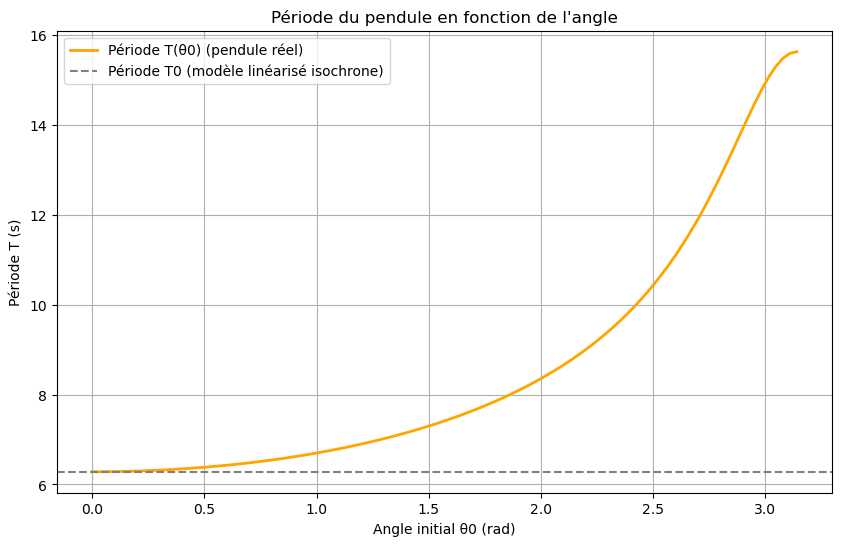

In [68]:
# Création d'un tableau d'angles theta0
theta0_valeurs = np.linspace(0, np.pi, 100)

# Calcul des périodes pour chaque angle
periodes = [gauss_legendre_3pts(integrande, th) for th in theta0_valeurs]

# Tracé
plt.figure(figsize=(10, 6))
plt.plot(theta0_valeurs, periodes, label="Période T(θ0) (pendule réel)", color='orange', linewidth=2)

# Période du pendule linéarisé T0 = 2*pi/omega pour comparer
T0 = 2 * np.pi / 1.0
plt.axhline(y=T0, color='gray', linestyle='--', label="Période T0 (modèle linéarisé isochrone)")

plt.title("Période du pendule en fonction de l'angle")
plt.xlabel("Angle initial θ0 (rad)")
plt.ylabel("Période T (s)")
plt.legend()
plt.grid(True)
plt.show()

**Observation :** Sur le graphique, on voit clairement que la période $T(\theta_0)$ n'est pas constante. Elle augmente avec l'amplitude de lâcher $\theta_0$, s'éloignant de plus en plus de la ligne droite $T_0$ du modèle linéarisé. 

**Conclusion :** Le pendule réel n'est pas isochrone. Le modèle linéarisé n'est valable que pour les très petits angles (près de $0$).

**Comportement près de $\pi$ :** Lorsque l'angle de lâcher s'approche de $\pi$ (c'est-à-dire lorsque le pendule est lâché presque à la verticale, à l'envers), la période tend vers l'infini. Physiquement, cela signifie que le pendule va mettre un temps infiniment long à redescendre, car il est lâché extrêmement près d'une position d'équilibre instable où la force de pesanteur est presque nulle.

### 3. Comparaison des méthodes d'intégration

**1. Degré d'exactitude :**
* **Méthode de Simpson :** D'après le cours, la méthode de Simpson classique est exacte pour les polynômes de degré $\le 3$.
* **Méthode de Gauss-Legendre à 3 points :** La méthode de Gauss maximise le degré d'exactitude. Pour $3$ points (ce qui correspond à $n=2$ dans le cours), la méthode est d'ordre $2(2)+2=6$, ce qui signifie qu'elle est exacte pour les polynômes de degré $\le 5$.

**2. Nombre d'évaluations de la fonction :**
* **Simpson composite ($N=2$ sous-intervalles) :** La méthode évalue la fonction aux extrémités et au milieu de chaque sous-intervalle. Pour 2 intervalles accolés, il y a 3 points pour le premier intervalle, et 2 points supplémentaires pour le second (le point de bordure étant partagé). Cela fait un total de 5 évaluations.
* **Gauss-Legendre à 3 points :** Par définition, la méthode évalue la fonction uniquement aux abscisses correspondant aux racines du polynôme orthogonal. Elle nécessite donc exactement 3 évaluations.

**3. Conclusion sur l'efficacité :**
La méthode de Gauss-Legendre à 3 points est numériquement beaucoup plus efficace. Elle nécessite moins de calculs de la fonction (3 évaluations contre 5 pour Simpson composite) tout en offrant une précision théorique nettement supérieure (exacte jusqu'au degré 5, contre le degré 3 pour Simpson). C'est pour cela qu'elle est souvent privilégiée pour les intégrales complexes.

## Partie 3 : Points d’équilibre et valeurs propres

### 1. Recherche analytique

En reprenant le système différentiel d'ordre 1, on obtient l'équation vectorielle suivante :
$$\begin{pmatrix} v_{eq} \\ -\omega^2 \sin(\theta_{eq}) \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \end{pmatrix}$$

Ce qui se traduit par le système :
$$\begin{cases} v_{eq} = 0 \\ \sin(\theta_{eq}) = 0 \end{cases}$$
(On a toujours $\omega = 1$ d'après l'énoncé, donc ce terme ne peut pas être nul).

Sur $[-\pi, \pi]$, l'équation $\sin(\theta_{eq}) = 0$ admet trois solutions : $-\pi$, $0$, et $\pi$.
    
On trouve donc trois points d'équilibre physiques pour le pendule :
* $(0, 0)$ : C'est la position où le pendule est "au repos", suspendu à la verticale vers le bas.
* $(\pi, 0)$ et $(-\pi, 0)$ : Dans ces deux cas, le pendule est dressé exactement à la verticale vers le haut.

### 2. Linéarisation

Le système s'écrit $Y'(t) = F(\theta, v)$ avec $F_1(\theta, v) = v$ et $F_2(\theta, v) = -\omega^2 \sin(\theta)$.
La matrice Jacobienne $J(\theta, v)$ est donc :
$$J(\theta, v) = \begin{pmatrix} \frac{\partial F_1}{\partial \theta} & \frac{\partial F_1}{\partial v} \\ \frac{\partial F_2}{\partial \theta} & \frac{\partial F_2}{\partial v} \end{pmatrix} = \begin{pmatrix} 0 & 1 \\ -\omega^2 \cos(\theta) & 0 \end{pmatrix}$$

### 3. Valeurs propres et stabilité (Théorie)

**1. Point d'équilibre bas ($\theta = 0$, $v = 0$) :**
La matrice Jacobienne s'écrit $J(0,0) = \begin{pmatrix} 0 & 1 \\ -\omega^2 & 0 \end{pmatrix}$.
Le polynôme caractéristique est $\det(J - \lambda I) = \lambda^2 + \omega^2 = 0$.
Les valeurs propres sont donc : $\lambda_1 = i\omega$ et $\lambda_2 = -i\omega$.
**Conclusion :** Le point est stable. La partie réelle des valeurs propres étant nulle, le système oscille indéfiniment autour de ce point sans s'en éloigner ni s'y écraser, ce qui correspond au mouvement perpétuel du pendule sans frottement.

**2. Point d'équilibre haut ($\theta = \pi$, $v = 0$) :**
La matrice Jacobienne s'écrit $J(\pi,0) = \begin{pmatrix} 0 & 1 \\ \omega^2 & 0 \end{pmatrix}$.
Le polynôme caractéristique est $\det(J - \lambda I) = \lambda^2 - \omega^2 = 0$.
Les valeurs propres sont donc : $\lambda_1 = \omega$ et $\lambda_2 = -\omega$.
**Conclusion :** La présence d'une valeur propre strictement positive ($\lambda_1 = \omega > 0$) indique que ce point d'équilibre est instable. La moindre petite perturbation éloignera exponentiellement le pendule de cette position verticale.

**Lien avec l'observation physique :**
Dans la partie précédente, on a observé que la période tendait vers l'infini lorsque l'angle de lâcher s'approchait de $\pi$. Cela s'explique désormais mathématiquement : la trajectoire du pendule passe infiniment près de ce point d'équilibre instable. Au voisinage de ce point, l'accélération devient presque nulle. Le pendule va donc "stagner" et mettre un temps infiniment long à franchir cette zone avant de retomber.

### 4. Implémentation Python et limites de la méthode de la puissance

In [73]:
import numpy as np

# 1. Fonction pour générer la matrice Jacobienne
def jacobienne(theta, omega=1.0):
    return np.array([[0.0, 1.0],
                     [- (omega**2) * np.cos(theta), 0.0]])

# 2. Implémentation de la méthode de la puissance
def methode_puissance(A, iter_max=50):
    x = np.array([1.0, 1.0])
    
    print("- Dernières itérations -")
    for k in range(iter_max):
        y = x / np.linalg.norm(x)
        
        x = np.dot(A, y)
        
        mu = np.dot(y, np.dot(A, y))
        
        if k >= iter_max - 5:
            print(f"Itération {k} : mu = {mu:.5f}")
            
    return mu, y

# Test sur le point bas (theta = 0)
print(">>> POINT D'ÉQUILIBRE BAS (theta = 0) <<<")
J_bas = jacobienne(0.0)
print("Tentative avec la méthode de la puissance :")
methode_puissance(J_bas)

# Alternative
valeurs_propres_bas, vecteurs_propres_bas = np.linalg.eig(J_bas)
print(f"\nValeurs propres exactes : {valeurs_propres_bas}\n")


# Test sur le point haut (theta = pi)
print(">>> POINT D'ÉQUILIBRE HAUT (theta = pi) <<<")
J_haut = jacobienne(np.pi)
print("Tentative avec la méthode de la puissance :")
methode_puissance(J_haut)

# Alternative
valeurs_propres_haut, vecteurs_propres_haut = np.linalg.eig(J_haut)
print(f"\nValeurs propres exactes : {valeurs_propres_haut}")

>>> POINT D'ÉQUILIBRE BAS (theta = 0) <<<
Tentative avec la méthode de la puissance :
- Dernières itérations -
Itération 45 : mu = 0.00000
Itération 46 : mu = 0.00000
Itération 47 : mu = 0.00000
Itération 48 : mu = 0.00000
Itération 49 : mu = 0.00000

Valeurs propres exactes : [0.+1.j 0.-1.j]

>>> POINT D'ÉQUILIBRE HAUT (theta = pi) <<<
Tentative avec la méthode de la puissance :
- Dernières itérations -
Itération 45 : mu = 1.00000
Itération 46 : mu = 1.00000
Itération 47 : mu = 1.00000
Itération 48 : mu = 1.00000
Itération 49 : mu = 1.00000

Valeurs propres exactes : [ 1. -1.]


**Observation numérique :** L'implémentation de la méthode de la puissance échoue à converger vers une valeur propre stable pour les deux points d'équilibre. Les estimations oscillent ou ne se stabilisent pas, tandis que la fonction alternative `numpy.linalg.eig` nous renvoie instantanément les bonnes valeurs théoriques.

**Réflexion :**
D'après le théorème de convergence de la méthode de la puissance du cours, la matrice doit posséder une valeur propre dominante unique. Autrement dit, $|\lambda_1| > |\lambda_2| \ge \dots \ge |\lambda_n|$. 

Or, on a démontré dans la question précédente que ce n'est jamais le cas pour les deux points d'équilibre :
* Au point bas, les valeurs propres sont $\pm i\omega$, dont les modules sont identiques ($|i\omega| = |-i\omega| = \omega$).
* Au point haut, les valeurs propres sont $\pm \omega$, dont les modules sont également identiques ($|\omega| = |-\omega| = \omega$).

L'écart étant nul dans les deux cas, le vecteur approché ne peut pas s'aligner sur une unique direction dominante, ce qui entraîne l'échec de la convergence de l'algorithme.

## Partie 4 (Bonus) : Le pendule double et le chaos

### 1. Simulation

Avec les simplifications $m=m'=1$ et $L=L'=1$, les équations du mouvement s'écrivent :
$$\begin{cases} 2\ddot{\theta} + \ddot{\theta}'\cos(\theta-\theta') + (\dot{\theta}')^2\sin(\theta-\theta') + 2g\sin(\theta) = 0 \\
\ddot{\theta}' + \ddot{\theta}\cos(\theta-\theta') - \dot{\theta}^2\sin(\theta-\theta') + g\sin(\theta') = 0 \end{cases}$$

Soit encore :
$$\begin{cases} 2\ddot{\theta} + \cos(\theta-\theta')\ddot{\theta}' = -(\dot{\theta}')^2\sin(\theta-\theta') - 2g\sin(\theta) \\ \cos(\theta-\theta')\ddot{\theta} + \ddot{\theta}' = \dot{\theta}^2\sin(\theta-\theta') - g\sin(\theta') \end{cases}$$

En résolvant ce système par substitution et en posant $\Delta = \theta - \theta'$, on obtient les expressions suivantes :

$$\ddot{\theta} = \frac{-(\omega')^2\sin(\Delta) - 2g\sin(\theta) - \cos(\Delta) \left( \omega^2\sin(\Delta) - g\sin(\theta') \right)}{2 - \cos^2(\Delta)}$$

$$\ddot{\theta}' = \frac{2\left( \omega^2\sin(\Delta) - g\sin(\theta') \right) - \cos(\Delta) \left( -(\omega')^2\sin(\Delta) - 2g\sin(\theta) \right)}{2 - \cos^2(\Delta)}$$

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# 1. La fonction dynamique du pendule double F(Y)
def dynamique_pendule_double(t, Y):
    g = 9.81
    
    theta, theta_prime, omega, omega_prime = Y
    
    delta = theta - theta_prime
    
    D = 2.0 - np.cos(delta)**2
    
    theta_pt = -(omega_prime**2) * np.sin(delta) - 2.0 * g * np.sin(theta) - np.cos(delta) * ((omega**2) * np.sin(delta) - g * np.sin(theta_prime))
    acc = theta_pt / D
    
    theta_pt_prime = 2.0 * ((omega**2) * np.sin(delta) - g * np.sin(theta_prime)) - np.cos(delta) * (-(omega_prime**2) * np.sin(delta) - 2.0 * g * np.sin(theta))
    acc_prime = theta_pt_prime / D
    
    return np.array([omega, omega_prime, acc, acc_prime])

# 2. L'algorithme RK4
def rk4_bis(F, t_max, Y0, h):
    t = np.arange(0.0, t_max + h, h)
    N = len(t)
    
    Y = np.zeros((N, len(Y0)))
    Y[0] = Y0
    
    for i in range(N - 1):
        k1 = F(t[i], Y[i])
        k2 = F(t[i] + h/2.0, Y[i] + (h/2.0)*k1)
        k3 = F(t[i] + h/2.0, Y[i] + (h/2.0)*k2)
        k4 = F(t[i] + h, Y[i] + h*k3)
        
        Y[i+1] = Y[i] + (h/6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)
        
    return t, Y

# 3. Simulation sur 10 secondes
Y0_test = np.array([np.pi/2.0, np.pi/2.0, 0.0, 0.0]) 
t_sim, Y_sim = rk4_bis(dynamique_pendule_double, 10.0, Y0_test, 0.01)

print("Simulation du pendule double terminée !")
print(f"Forme du tableau de résultats : {Y_sim.shape} (Les 4 colonnes correspondent aux 4 variables)")

Simulation du pendule double terminée !
Forme du tableau de résultats : (1001, 4) (Les 4 colonnes correspondent aux 4 variables)


### 2. Trajectoire spatiale

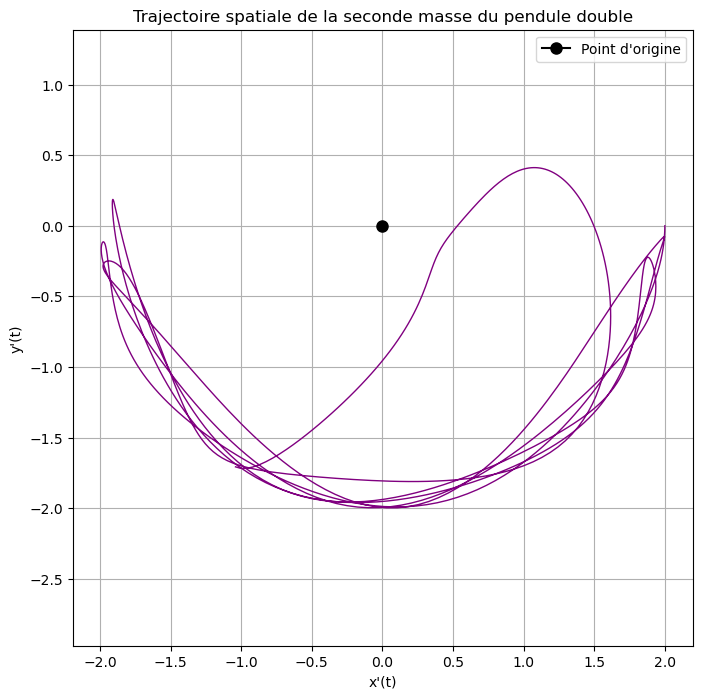

In [80]:
# Extraction des angles du tableau de résultats
theta_sim = Y_sim[:, 0]
theta_prime_sim = Y_sim[:, 1]

# Calcul des coordonnées cartésiennes de la seconde masse
x_prime = np.sin(theta_sim) + np.sin(theta_prime_sim)
y_prime = -np.cos(theta_sim) - np.cos(theta_prime_sim)

# Tracé de la trajectoire spatiale
plt.figure(figsize=(8, 8))
plt.plot(x_prime, y_prime, color='purple', linewidth=1)

# Point d'origine (premier pendule)
plt.plot(0, 0, marker='o', markersize=8, color='black', label="Point d'origine")

plt.title("Trajectoire spatiale de la seconde masse du pendule double")
plt.xlabel("x'(t)")
plt.ylabel("y'(t)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

**Observation :** On obtient une courbe extrêmement complexe qui s'entremêle sans jamais repasser exactement au même endroit.

**Conclusion :** Le mouvement n'est pas du tout périodique. Contrairement au pendule simple de la partie précédente qui dessinait des cycles parfaits, le pendule double présente une trajectoire très imprévisible, caractéristique d'un système chaotique.

### 3. Sensibilité aux conditions initiales (le chaos)

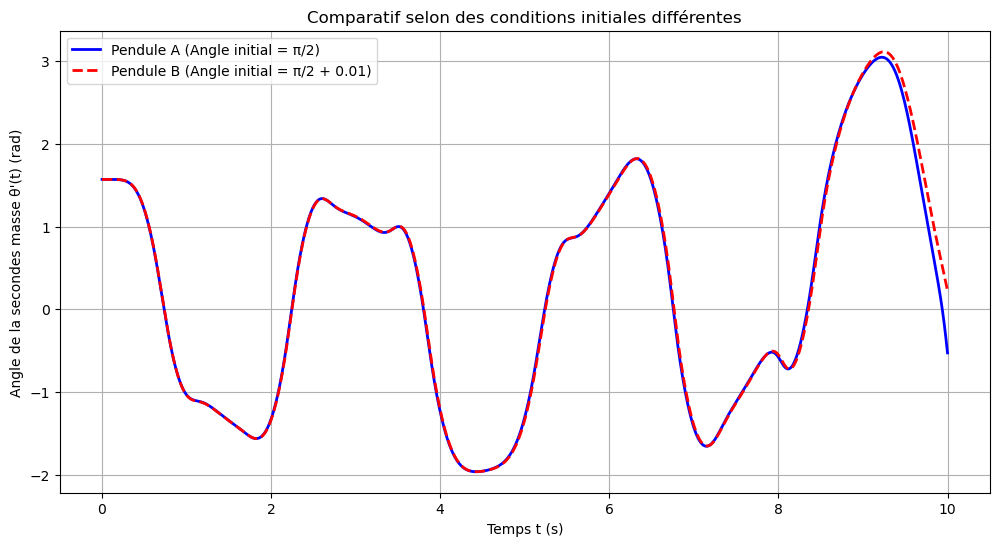

In [84]:
# Pendule A
Y0_A = np.array([np.pi/2.0, np.pi/2.0, 0.0, 0.0])

#Pendule B
Y0_B = np.array([np.pi/2.0 + 0.01, np.pi/2.0, 0.0, 0.0])

# Simulations des deux pendules sur 10 secondes
t_sim, Y_A = rk4_bis(dynamique_pendule_double, 10.0, Y0_A, 0.01)
_, Y_B = rk4_bis(dynamique_pendule_double, 10.0, Y0_B, 0.01)

# Extraction de l'angle de la seconde masse
theta_prime_A = Y_A[:, 1]
theta_prime_B = Y_B[:, 1]

# Tracé
plt.figure(figsize=(12, 6))
plt.plot(t_sim, theta_prime_A, label="Pendule A (Angle initial = π/2)", color='blue', linewidth=2)
plt.plot(t_sim, theta_prime_B, label="Pendule B (Angle initial = π/2 + 0.01)", color='red', linestyle='--', linewidth=2)

plt.title("Comparatif selon des conditions initiales différentes")
plt.xlabel("Temps t (s)")
plt.ylabel("Angle de la secondes masse θ'(t) (rad)")
plt.legend()
plt.grid(True)
plt.show()

**Observation :** Pendant les 8 premières secondes de la simulation, les courbes $\theta'(t)$ des pendules A et B restent parfaitement superposées. Cependant, aux alentours de $t \approx 8.5$ secondes, les deux trajectoires commencent à se séparer visiblement. À $t = 10$ secondes, l'écart est devenu flagrant et les pendules n'ont plus du tout la même position, bien qu'ils n'aient été décalés que de $10^{-2}$ radian au départ.

**Conclusion physique :** Cette divergence illustre parfaitement la notion de système chaotique. Dans le pendule double, une perturbation infime sur les conditions initiales est amplifiée exponentiellement au fil du temps. Conséquence directe : il est physiquement impossible de prédire l'état du système à long terme. La moindre incertitude initiale ruine totalement les prévisions de l'algorithme après quelques secondes.